# 03 — Sensitivity Analysis: DV01 & Key Rate Durations

**Fixed Income Analytics** | Palma, R. (2026)

This notebook implements and visualizes interest rate
sensitivity for single bonds and portfolios using the
full yield curve from Module 2.

### Contents
1. Setup: curve and bonds
2. Parallel shift DV01
3. Key Rate Durations: single bond
4. Interactive KRD explorer
5. Portfolio sensitivity
6. Scenario analysis
7. Hedge ratios

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from ipywidgets import interactive_output
from IPython.display import display
import warnings
import os
warnings.filterwarnings("ignore")

sys.path.append("..")
from src.bonds       import VanillaBond
from src.curves      import DiscountCurve, Bootstrapper, CurveInterpolator
from src.sensitivity import BondSensitivity, PortfolioSensitivity

os.makedirs("../figures", exist_ok=True)

plt.rcParams.update({
    "figure.figsize":    (12, 5),
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "serif",
})

print("✓ Imports OK")

✓ Imports OK


---
## 1. Setup: Curve and Bonds

We build a realistic upward-sloping yield curve and
three bonds with different maturities to illustrate
how sensitivity varies across the curve.

In [2]:
# ── Yield curve ───────────────────────────────────────────────
t_obs = np.array([1., 2., 3., 5., 7., 10., 20., 30.])
r_obs = np.array([0.040, 0.042, 0.045, 0.048,
                  0.050, 0.052, 0.055, 0.057])

curve = DiscountCurve(t_obs, r_obs)

# ── Three bonds ───────────────────────────────────────────────
bond_short  = VanillaBond(0.04, 1000, 2,  1)  # 2y  4% coupon
bond_medium = VanillaBond(0.05, 1000, 7,  1)  # 7y  5% coupon
bond_long   = VanillaBond(0.05, 1000, 30, 1)  # 30y 5% coupon
bond_zc     = VanillaBond(0.00, 1000, 10, 1)  # 10y zero coupon

bonds  = [bond_short, bond_medium, bond_long, bond_zc]
labels = ["2y 4%", "7y 5%", "30y 5%", "10y Zero Coupon"]

# ── Sensitivities ─────────────────────────────────────────────
sensitivities = [BondSensitivity(b, curve) for b in bonds]

print("Bond overview:")
print(f"\n{'Bond':>18} {'Price':>10} {'DV01':>10} "
      f"{'Mod Dur':>10}")
print("-" * 52)
for label, s in zip(labels, sensitivities):
    sm = s.summary()
    print(f"{label:>18} {sm['price']:>10.4f} "
          f"{sm['dv01_parallel']:>10.4f} "
          f"{sm['mod_duration']:>10.4f}")

Bond overview:

              Bond      Price       DV01    Mod Dur
----------------------------------------------------
             2y 4%   994.6401     0.1951     1.9614
             7y 5%   995.7282     0.6037     6.0627
            30y 5%   907.9083     1.3716    15.1076
   10y Zero Coupon   594.5205     0.5945    10.0000


---
## 2. Parallel Shift DV01

DV01 measures the price change for a 1bp parallel
shift of the entire curve:

$$\text{DV01} = \frac{P(r-\varepsilon) - P(r+\varepsilon)}{2}
\quad \varepsilon = 0.0001$$

Key observation: longer maturity → higher DV01.

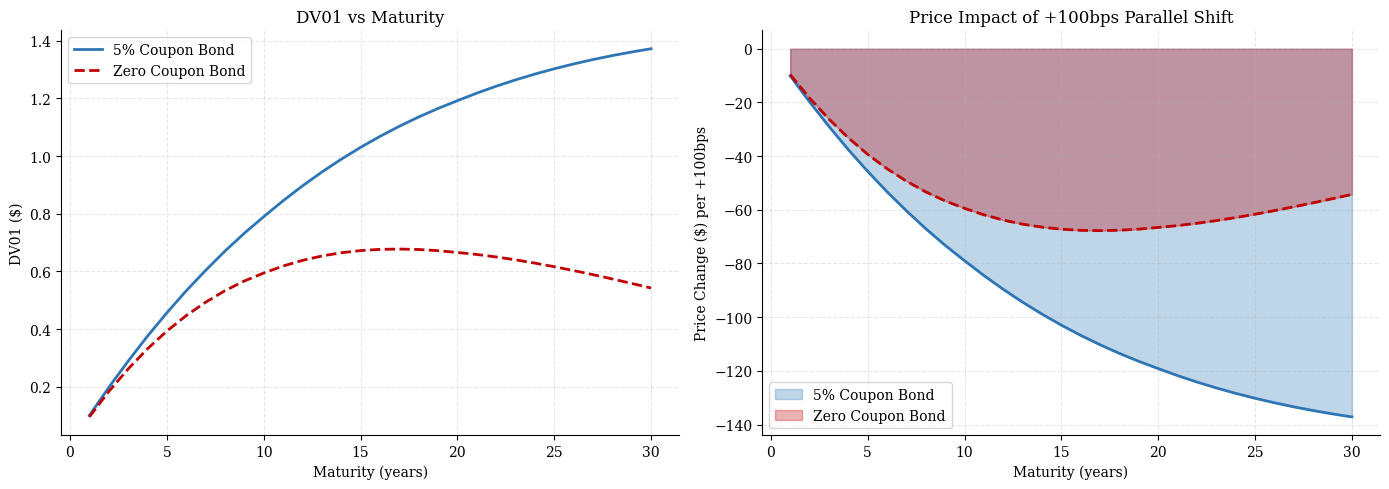

In [3]:
# DV01 across a range of maturities
maturities_range = np.arange(1, 31)
dv01_range       = []

for mat in maturities_range:
    b = VanillaBond(0.05, 1000, mat, 1)
    s = BondSensitivity(b, curve)
    dv01_range.append(s.dv01_parallel())

# DV01 for zero coupon bonds
dv01_zc = []
for mat in maturities_range:
    b = VanillaBond(0.00, 1000, mat, 1)
    s = BondSensitivity(b, curve)
    dv01_zc.append(s.dv01_parallel())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: DV01 vs maturity ────────────────────────────────────
axes[0].plot(maturities_range, dv01_range,
             color="#2E75B6", lw=2,
             label="5% Coupon Bond")
axes[0].plot(maturities_range, dv01_zc,
             color="#C00000", lw=2, ls="--",
             label="Zero Coupon Bond")
axes[0].set_xlabel("Maturity (years)")
axes[0].set_ylabel("DV01 ($)")
axes[0].set_title("DV01 vs Maturity")
axes[0].legend()

# ── Right: Price change for 100bps shift ──────────────────────
dP_100 = [dv01 * 100 for dv01 in dv01_range]
dP_zc  = [dv01 * 100 for dv01 in dv01_zc]

axes[1].fill_between(maturities_range,
                     [-x for x in dP_100], 0,
                     alpha=0.3, color="#2E75B6",
                     label="5% Coupon Bond")
axes[1].fill_between(maturities_range,
                     [-x for x in dP_zc], 0,
                     alpha=0.3, color="#C00000",
                     label="Zero Coupon Bond")
axes[1].plot(maturities_range,
             [-x for x in dP_100],
             color="#2E75B6", lw=2)
axes[1].plot(maturities_range,
             [-x for x in dP_zc],
             color="#C00000", lw=2, ls="--")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Price Change ($) per +100bps")
axes[1].set_title("Price Impact of +100bps Parallel Shift")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/03_dv01_vs_maturity.png", dpi=150)
plt.show()

---
## 3. Key Rate Durations: Single Bond

KRD decomposes total sensitivity into contributions
from each point on the curve:

$$KRD_k = \frac{P(r(t_k)-\varepsilon) -
P(r(t_k)+\varepsilon)}{2\varepsilon \cdot P}$$

**Additivity property:**
$$\sum_k KRD_k = D_{\text{mod}}$$

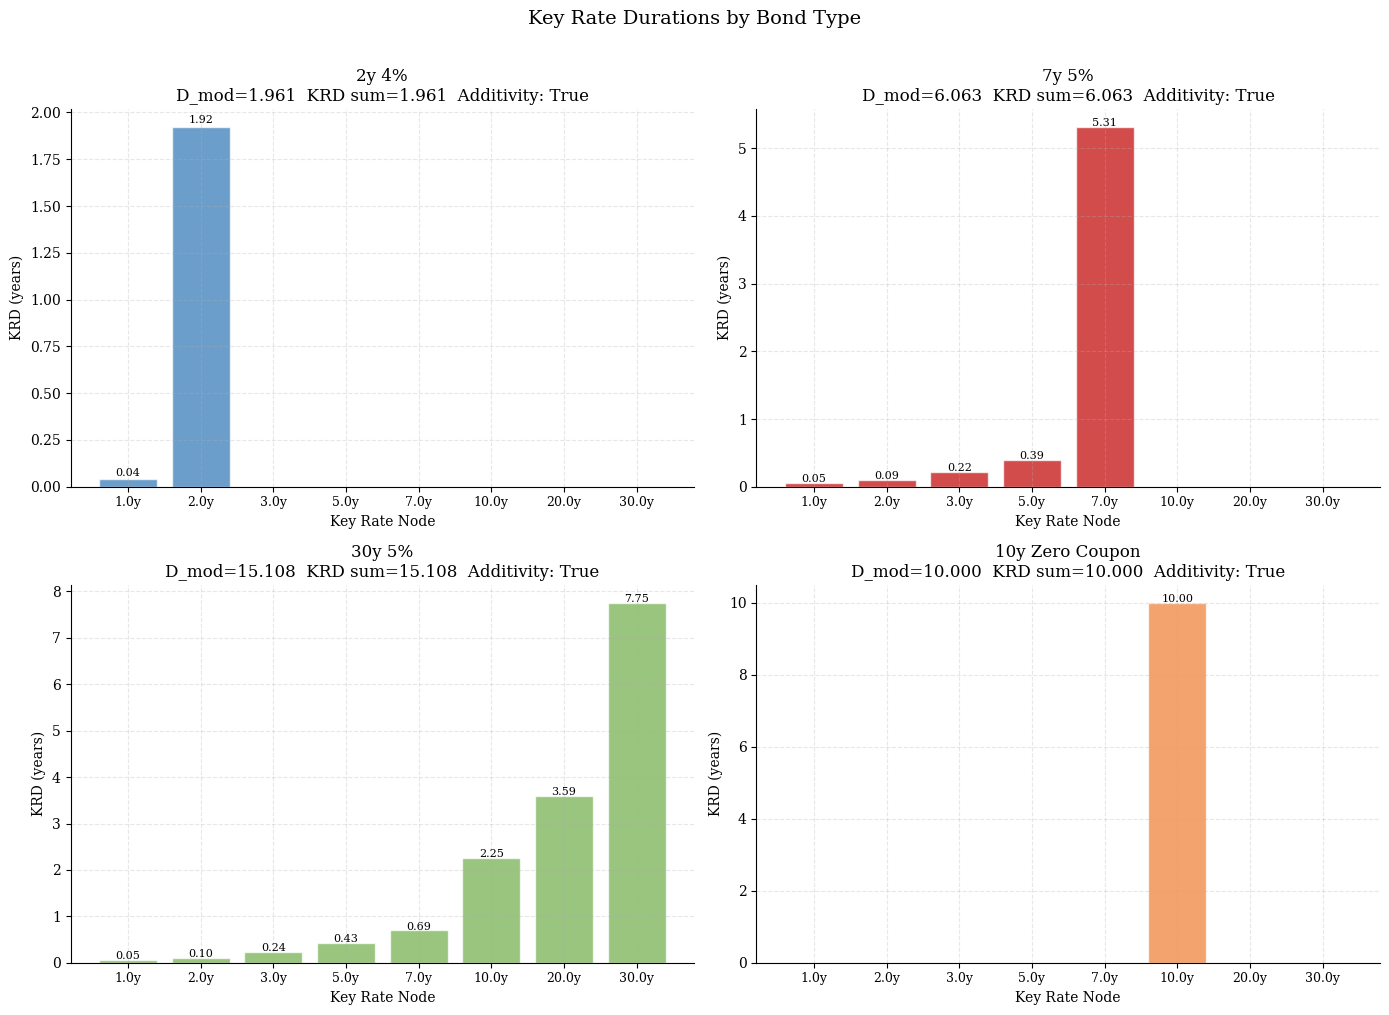


Additivity validation:
              Bond      D_mod    KRD sum    Match
--------------------------------------------------
             2y 4%     1.9614     1.9614        ✓
             7y 5%     6.0627     6.0627        ✓
            30y 5%    15.1076    15.1076        ✓
   10y Zero Coupon    10.0000    10.0000        ✓


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ["#2E75B6", "#C00000", "#70AD47", "#ED7D31"]

for ax, label, s, color in zip(
        axes, labels, sensitivities, colors):

    sm    = s.summary()
    nodes = list(sm["krd"].keys())
    krds  = list(sm["krd"].values())

    ax.bar(range(len(nodes)), krds,
           color=color, alpha=0.7, edgecolor="white")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xticks(range(len(nodes)))
    ax.set_xticklabels([f"{t}y" for t in nodes],
                       fontsize=9)
    ax.set_xlabel("Key Rate Node")
    ax.set_ylabel("KRD (years)")
    ax.set_title(
        f"{label}\n"
        f"D_mod={sm['mod_duration']:.3f}  "
        f"KRD sum={sm['krd_sum']:.3f}  "
        f"Additivity: {sm['additivity_ok']}"
    )

    # Annotate bars
    for i, (node, krd) in enumerate(
            zip(nodes, krds)):
        if abs(krd) > 0.01:
            ax.text(i, krd + 0.02,
                    f"{krd:.2f}",
                    ha="center", fontsize=8)

plt.suptitle("Key Rate Durations by Bond Type",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/03_krd_by_bond.png", dpi=150)
plt.show()

# Additivity validation
print("\nAdditivity validation:")
print(f"{'Bond':>18} {'D_mod':>10} "
      f"{'KRD sum':>10} {'Match':>8}")
print("-" * 50)
for label, s in zip(labels, sensitivities):
    sm = s.summary()
    print(f"{label:>18} "
          f"{sm['mod_duration']:>10.4f} "
          f"{sm['krd_sum']:>10.4f} "
          f"{'✓' if sm['additivity_ok'] else '✗':>8}")

---
## 4. Interactive KRD Explorer

Explore how the KRD profile changes with bond
characteristics. Notice:

- **Short bonds:** KRD concentrated at short nodes
- **Long bonds:** KRD spread across all nodes
- **Zero coupon:** KRD concentrated at a single node
- **High coupon:** KRD shifts toward shorter nodes

In [5]:
def plot_krd_explorer(coupon_rate, maturity,
                      frequency, face_value):
    """Interactive KRD explorer."""
    try:
        b  = VanillaBond(coupon_rate / 100,
                         face_value,
                         int(maturity),
                         int(frequency))
        s  = BondSensitivity(b, curve)
        sm = s.summary()

        nodes = list(sm["krd"].keys())
        krds  = list(sm["krd"].values())
        dv01s = list(sm["dv01_by_krd"].values())

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ── Left: KRD bars ────────────────────────────────────
        ax = axes[0]
        bars = ax.bar(range(len(nodes)), krds,
                      color="#2E75B6", alpha=0.7,
                      edgecolor="white")
        ax.axhline(0, color="black", lw=0.5)
        ax.set_xticks(range(len(nodes)))
        ax.set_xticklabels([f"{t}y" for t in nodes])
        ax.set_xlabel("Key Rate Node")
        ax.set_ylabel("KRD (years)")
        ax.set_title(
            f"Key Rate Duration Profile\n"
            f"D_mod={sm['mod_duration']:.3f}  "
            f"KRD sum={sm['krd_sum']:.3f}"
        )

        # ── Right: DV01 bars ──────────────────────────────────
        ax = axes[1]
        ax.bar(range(len(nodes)),
               [d * 100 for d in dv01s],
               color="#C00000", alpha=0.7,
               edgecolor="white")
        ax.axhline(0, color="black", lw=0.5)
        ax.set_xticks(range(len(nodes)))
        ax.set_xticklabels([f"{t}y" for t in nodes])
        ax.set_xlabel("Key Rate Node")
        ax.set_ylabel("DV01 × 100 ($)")
        ax.set_title(
            f"DV01 by Key Rate Node\n"
            f"Total DV01=${sm['dv01_parallel']:.4f}  "
            f"Price=${sm['price']:.2f}"
        )

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# ── Widgets ───────────────────────────────────────────────────
style  = {"description_width": "120px"}
layout = widgets.Layout(width="500px")

w_coupon = widgets.FloatSlider(
    value=5.0, min=0.0, max=12.0, step=0.5,
    description="Coupon rate (%):",
    style=style, layout=layout,
    readout_format=".1f"
)
w_maturity = widgets.IntSlider(
    value=10, min=1, max=30, step=1,
    description="Maturity (years):",
    style=style, layout=layout
)
w_frequency = widgets.Dropdown(
    options=[("Annual (1)", 1),
             ("Semi-annual (2)", 2),
             ("Quarterly (4)", 4)],
    value=1,
    description="Frequency:",
    style=style, layout=layout
)
w_face = widgets.Dropdown(
    options=[("$1,000", 1000),
             ("$100", 100),
             ("$10,000", 10000)],
    value=1000,
    description="Face value:",
    style=style, layout=layout
)

# ── Preset buttons ────────────────────────────────────────────
def set_short(_):
    w_coupon.value=4; w_maturity.value=2
def set_medium(_):
    w_coupon.value=5; w_maturity.value=7
def set_long(_):
    w_coupon.value=5; w_maturity.value=30
def set_zc(_):
    w_coupon.value=0; w_maturity.value=10

btn_short  = widgets.Button(description="2y Bond",
                             button_style="info")
btn_medium = widgets.Button(description="7y Bond",
                             button_style="")
btn_long   = widgets.Button(description="30y Bond",
                             button_style="warning")
btn_zc     = widgets.Button(description="Zero Coupon",
                             button_style="danger")

btn_short.on_click(set_short)
btn_medium.on_click(set_medium)
btn_long.on_click(set_long)
btn_zc.on_click(set_zc)

out = interactive_output(
    plot_krd_explorer,
    {"coupon_rate": w_coupon,
     "maturity":    w_maturity,
     "frequency":   w_frequency,
     "face_value":  w_face}
)

display(widgets.HTML("<h4>Presets:</h4>"))
display(widgets.HBox([btn_short, btn_medium,
                      btn_long, btn_zc]))
display(widgets.HTML("<br><h4>Parameters:</h4>"))
display(widgets.VBox([w_coupon, w_maturity,
                      w_frequency, w_face]))
display(out)

HTML(value='<h4>Presets:</h4>')

HTML(value='<br><h4>Parameters:</h4>')

Output()

---
## 5. Portfolio Sensitivity

A portfolio of three bonds. The KRD vector shows
which parts of the curve drive total risk.

In [6]:
# ── Build portfolio ───────────────────────────────────────────
port = PortfolioSensitivity(
    bonds   = [bond_short, bond_medium, bond_long],
    curve   = curve,
    weights = [10, 5, 2],
    labels  = ["2y 4%", "7y 5%", "30y 5%"]
)

# ── Summary table ─────────────────────────────────────────────
df = port.summary_table()
print("Portfolio Sensitivity Summary:")
print(df.to_string())

print(f"\nTotal Portfolio Value: "
      f"${port.portfolio_value():,.2f}")
print(f"Total DV01:           "
      f"${port.dv01_parallel():.4f}")

Portfolio Sensitivity Summary:
          Units     Price        MV  DV01 (parallel)  KRD 1.0y  KRD 2.0y  KRD 3.0y  KRD 5.0y  KRD 7.0y  KRD 10.0y  KRD 20.0y  KRD 30.0y
Bond                                                                                                                                   
2y 4%        10  994.6401   9946.40           1.9508    0.0386    1.9227    0.0000    0.0000    0.0000     0.0000     0.0000     0.0000
7y 5%         5  995.7282   4978.64           3.0184    0.0482    0.0923    0.2150    0.3932    5.3139     0.0000     0.0000     0.0000
30y 5%        2  907.9083   1815.82           2.7433    0.0529    0.1013    0.2358    0.4312    0.6947     2.2506     3.5879     7.7531
PORTFOLIO                  16740.86           7.7125    0.0430    1.1808    0.0895    0.1637    1.6557     0.2441     0.3892     0.8410

Total Portfolio Value: $16,740.86
Total DV01:           $7.7125


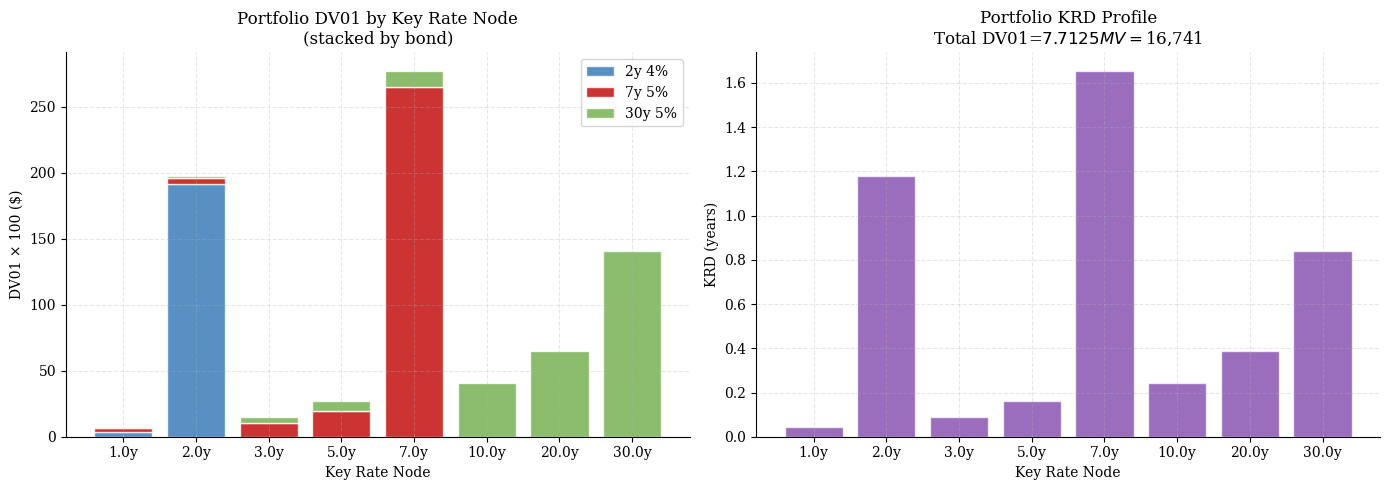

In [7]:
port_krds  = port.key_rate_durations()
port_dv01s = port.dv01_by_key_rate()
nodes      = list(port_krds.keys())

# Individual DV01s stacked
ind_dv01s = []
for w, s in zip(port.weights, port._sensitivities):
    d = s.dv01_by_key_rate()
    ind_dv01s.append(
        [w * d.get(t, 0) for t in nodes])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_p   = ["#2E75B6", "#C00000", "#70AD47"]

# ── Left: Stacked DV01 ────────────────────────────────────────
ax     = axes[0]
bottom = np.zeros(len(nodes))
for i, (label, dv01_vec) in enumerate(
        zip(port.labels, ind_dv01s)):
    ax.bar(range(len(nodes)),
           [d * 100 for d in dv01_vec],
           bottom=bottom * 100,
           label=label,
           color=colors_p[i],
           alpha=0.8, edgecolor="white")
    bottom += np.array(dv01_vec)

ax.set_xticks(range(len(nodes)))
ax.set_xticklabels([f"{t}y" for t in nodes])
ax.set_xlabel("Key Rate Node")
ax.set_ylabel("DV01 × 100 ($)")
ax.set_title("Portfolio DV01 by Key Rate Node\n"
             "(stacked by bond)")
ax.legend()

# ── Right: Portfolio KRD ─────────────────────────────────────
ax = axes[1]
ax.bar(range(len(nodes)),
       list(port_krds.values()),
       color="#7030A0", alpha=0.7,
       edgecolor="white")
ax.set_xticks(range(len(nodes)))
ax.set_xticklabels([f"{t}y" for t in nodes])
ax.set_xlabel("Key Rate Node")
ax.set_ylabel("KRD (years)")
ax.set_title(
    f"Portfolio KRD Profile\n"
    f"Total DV01=${port.dv01_parallel():.4f}  "
    f"MV=${port.portfolio_value():,.0f}"
)

plt.tight_layout()
plt.savefig("../figures/03_portfolio_krd.png", dpi=150)
plt.show()

---
## 6. Scenario Analysis

Approximate P&L under non-parallel curve shifts:

$$\Delta V \approx -\mathbf{DV01} \cdot
\frac{\Delta \mathbf{r}}{0.0001}$$

Three scenarios:
- **Bear flattener:** short rates up, long rates less
- **Bull steepener:** short rates down, long rates less
- **Parallel +100bps:** all rates up by 100bps

In [8]:
def plot_scenario(short_shift, medium_shift, long_shift):
    """Interactive scenario P&L analysis."""
    n = len(nodes)

    # Build shift vector interpolated across nodes
    shift_vec = np.interp(
        nodes,
        [nodes[0], nodes[len(nodes)//2], nodes[-1]],
        [short_shift/10000,
         medium_shift/10000,
         long_shift/10000]
    )

    pnl = port.scenario_pnl(shift_vec)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: Shift curve ─────────────────────────────────────
    ax = axes[0]
    ax.bar(range(n),
           shift_vec * 10000,
           color=["#C00000" if s > 0 else "#2E75B6"
                  for s in shift_vec],
           alpha=0.7, edgecolor="white")
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels([f"{t}y" for t in nodes])
    ax.set_xlabel("Key Rate Node")
    ax.set_ylabel("Shift (bps)")
    ax.set_title("Curve Shift Scenario")

    # ── Right: P&L ───────────────────────────────────────────
    ax = axes[1]
    color = "#70AD47" if pnl >= 0 else "#C00000"
    ax.bar(["Portfolio P&L"], [pnl],
           color=color, alpha=0.8,
           edgecolor="white", width=0.4)
    ax.axhline(0, color="black", lw=1)
    ax.set_ylabel("Approximate P&L ($)")
    ax.set_title(
        f"Scenario P&L\n"
        f"ΔV ≈ ${pnl:,.2f}"
    )

    # Annotate
    ax.text(0, pnl / 2,
            f"${pnl:,.2f}",
            ha="center", va="center",
            fontsize=14, fontweight="bold",
            color="white")

    plt.tight_layout()
    plt.show()

# ── Widgets ───────────────────────────────────────────────────
style_s  = {"description_width": "140px"}
layout_s = widgets.Layout(width="500px")

w_short = widgets.IntSlider(
    value=0, min=-200, max=200, step=5,
    description="Short end shift (bps):",
    style=style_s, layout=layout_s
)
w_medium = widgets.IntSlider(
    value=0, min=-200, max=200, step=5,
    description="Medium shift (bps):",
    style=style_s, layout=layout_s
)
w_long = widgets.IntSlider(
    value=0, min=-200, max=200, step=5,
    description="Long end shift (bps):",
    style=style_s, layout=layout_s
)

# ── Preset scenarios ──────────────────────────────────────────
def bear_flattener(_):
    w_short.value=100; w_medium.value=50
    w_long.value=25

def bull_steepener(_):
    w_short.value=-100; w_medium.value=-50
    w_long.value=-25

def parallel_up(_):
    w_short.value=100; w_medium.value=100
    w_long.value=100

def parallel_down(_):
    w_short.value=-100; w_medium.value=-100
    w_long.value=-100

def reset(_):
    w_short.value=0; w_medium.value=0
    w_long.value=0

btn_bf  = widgets.Button(description="Bear Flattener",
                          button_style="danger")
btn_bs  = widgets.Button(description="Bull Steepener",
                          button_style="success")
btn_pu  = widgets.Button(description="Parallel +100bps",
                          button_style="warning")
btn_pd  = widgets.Button(description="Parallel -100bps",
                          button_style="info")
btn_rst = widgets.Button(description="Reset",
                          button_style="")

btn_bf.on_click(bear_flattener)
btn_bs.on_click(bull_steepener)
btn_pu.on_click(parallel_up)
btn_pd.on_click(parallel_down)
btn_rst.on_click(reset)

out_scen = interactive_output(
    plot_scenario,
    {"short_shift":  w_short,
     "medium_shift": w_medium,
     "long_shift":   w_long}
)

display(widgets.HTML("<h4>Preset Scenarios:</h4>"))
display(widgets.HBox([btn_bf, btn_bs,
                      btn_pu, btn_pd, btn_rst]))
display(widgets.HTML("<br><h4>Custom Scenario:</h4>"))
display(widgets.VBox([w_short, w_medium, w_long]))
display(out_scen)

HTML(value='<h4>Preset Scenarios:</h4>')

HTML(value='<br><h4>Custom Scenario:</h4>')

Output()

---
## 7. Hedge Ratios

Given the portfolio exposure, compute the units of
hedging instruments needed to neutralize the DV01
vector via least squares.

In [9]:
# Hedging instruments
hedge_2y  = VanillaBond(0.04, 1000, 2,  1)
hedge_10y = VanillaBond(0.05, 1000, 10, 1)
hedge_30y = VanillaBond(0.05, 1000, 30, 1)

hedges       = [hedge_2y, hedge_10y, hedge_30y]
hedge_labels = ["Hedge 2y", "Hedge 10y", "Hedge 30y"]

ratios = port.hedge_ratios(hedges, hedge_labels)

print("Hedge Ratios (units of each instrument):")
print("-" * 40)
for label, ratio in ratios.items():
    direction = "SHORT" if ratio < 0 else "LONG"
    print(f"  {label:>12}: {ratio:>10.4f} "
          f"({direction})")

print(f"\nInterpretation:")
print(f"  Negative ratio = short position in hedge")
print(f"  Positive ratio = long position in hedge")

# Verify: post-hedge DV01 should be near zero
port_dv01_vec = np.array(
    list(port.dv01_by_key_rate().values()))

hedge_dv01_matrix = np.zeros(
    (len(t_obs), len(hedges)))

for j, hedge in enumerate(hedges):
    hs    = BondSensitivity(hedge, curve)
    dv01s = hs.dv01_by_key_rate()
    for k, t in enumerate(t_obs):
        hedge_dv01_matrix[k, j] = dv01s.get(
            float(t), 0)

h_vec        = np.array(list(ratios.values()))
residual_dv01 = port_dv01_vec + hedge_dv01_matrix @ h_vec

print(f"\nResidual DV01 after hedge "
      f"(should be near zero):")
for t, res in zip(t_obs, residual_dv01):
    print(f"  {t}y: ${res:.6f}")

Hedge Ratios (units of each instrument):
----------------------------------------
      Hedge 2y:   -10.2164 (SHORT)
     Hedge 10y:    -0.3464 (SHORT)
     Hedge 30y:    -2.1982 (SHORT)

Interpretation:
  Negative ratio = short position in hedge
  Positive ratio = long position in hedge

Residual DV01 after hedge (should be near zero):
  1.0y: $0.020572
  2.0y: $-0.000413
  3.0y: $0.095384
  5.0y: $0.174419
  7.0y: $2.611276
  10.0y: $-0.266347
  20.0y: $-0.064566
  30.0y: $-0.139522


---
## Key Observations

1. **DV01 grows with maturity:** longer bonds have
   more interest rate risk per dollar invested.

2. **Zero coupon bonds** concentrate all KRD at a
   single node — the maturity date. This is why
   they are the building blocks of the curve.

3. **KRD additivity:** sum of KRDs always equals
   Modified Duration. This is our validation check.

4. **Portfolio aggregation:** stacked DV01 bars show
   which bonds dominate the risk at each node.

5. **Bear flattener** hurts long-duration portfolios
   less than a parallel shift of the same magnitude —
   short rates rise more than long rates.

6. **Hedge ratios** from least squares may require
   short positions: this is economically correct and
   common in practice.